In [10]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

IMG_SIZE = 128
X, y = [], []

base_path = "/content/drive/MyDrive/LEADS"   # dataset/abnormal , dataset/normal

for label_name, label in [("ABNORMAL", 0), ("NORMAL", 1)]:
    folder = os.path.join(base_path, label_name)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        img = (img - img.mean()) / (img.std() + 1e-7)

        X.append(img)
        y.append(label)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y = np.array(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train = to_categorical(y_train, 2)
y_test  = to_categorical(y_test, 2)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (5376, 128, 128, 1)
Test : (1345, 128, 128, 1)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [59]:
import tensorflow as tf
from tensorflow.keras import layers, models

# -------------------------------
# Squash function (CapsNet core)
# -------------------------------
def squash(vectors, axis=-1):
    s_squared_norm = tf.reduce_sum(tf.square(vectors), axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm)
    return scale * vectors / tf.sqrt(s_squared_norm + 1e-7)

# -------------------------------
# Primary Capsule Layer
# -------------------------------
@tf.keras.utils.register_keras_serializable()
class PrimaryCaps(layers.Layer):
    def __init__(self, n_capsules, dim_capsule, kernel_size, strides):
        super().__init__()
        self.n_capsules = n_capsules
        self.dim_capsule = dim_capsule
        self.kernel_size = kernel_size
        self.strides = strides

        self.conv = layers.Conv2D(
            filters=n_capsules * dim_capsule,
            kernel_size=kernel_size,
            strides=strides,
            activation="relu",
            padding="valid"
        )

    def build(self, input_shape):
        h = (input_shape[1] - self.kernel_size) // self.strides + 1
        w = (input_shape[2] - self.kernel_size) // self.strides + 1
        self.num_caps = h * w * self.n_capsules
        super().build(input_shape)

    def call(self, inputs):
        x = self.conv(inputs)
        x = tf.reshape(x, (-1, self.num_caps, self.dim_capsule))
        return squash(x)

    def compute_output_shape(self, input_shape):
        h = (input_shape[1] - self.kernel_size) // self.strides + 1
        w = (input_shape[2] - self.kernel_size) // self.strides + 1
        return (input_shape[0],
                h * w * self.n_capsules,
                self.dim_capsule)


    def get_config(self):
        config = super().get_config()
        config.update({
            "n_capsules": self.n_capsules,
            "dim_capsule": self.dim_capsule,
            "kernel_size": self.kernel_size,
            "strides": self.strides,
        })
        return config


# -------------------------------
# Digit Capsule (Simplified & Stable)
# -------------------------------
class DigitCaps(layers.Layer):
    def __init__(self, num_capsules, dim_capsule, routing_iters=3):
        super().__init__()
        self.num_capsules = num_capsules
        self.dim_capsule = dim_capsule
        self.routing_iters = routing_iters

    def build(self, input_shape):
        self.num_input_caps = input_shape[1]
        self.input_dim = input_shape[2]

        self.W = self.add_weight(
            shape=(self.num_input_caps,
                   self.num_capsules,
                   self.input_dim,
                   self.dim_capsule),
            initializer='glorot_uniform',
            trainable=True
        )

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]

        inputs_expanded = tf.expand_dims(inputs, 2)
        inputs_expanded = tf.expand_dims(inputs_expanded, -1)

        W = tf.expand_dims(self.W, 0)
        W = tf.tile(W, [batch_size, 1, 1, 1, 1])

        u_hat = tf.matmul(
            tf.transpose(W, [0,1,2,4,3]),
            inputs_expanded
        )
        u_hat = tf.squeeze(u_hat, -1)

        b = tf.zeros_like(tf.reduce_sum(u_hat, axis=-1))

        for i in range(self.routing_iters):
            c = tf.nn.softmax(b, axis=-1)

            s = tf.reduce_sum(
                tf.expand_dims(c, -1) * u_hat,
                axis=1
            )

            v = squash(s)

            if i < self.routing_iters - 1:
                agreement = tf.reduce_sum(
                    u_hat * tf.expand_dims(v, 1),
                    axis=-1
                )
                b = b + agreement

        return v




def compute_output_shape(self, input_shape):
        return (input_shape[0], self.num_capsules, self.dim_capsule)



# -------------------------------
# MODEL DEFINITION (Subclassed)
# -------------------------------

class CapsNet(tf.keras.Model):
    def __init__(self):
        super().__init__()

        self.conv1 = layers.Conv2D(64, (9, 9), activation="relu")

        self.primary_caps = PrimaryCaps(
            n_capsules=8,
            dim_capsule=8,
            kernel_size=9,
            strides=2
        )

        self.digit_caps = DigitCaps(
            num_capsules=2,
            dim_capsule=16
        )

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.primary_caps(x)
        x = self.digit_caps(x)

        # Capsule length = probability
        length = tf.norm(x, axis=-1)
        return tf.nn.softmax(length)


# Build model
model = CapsNet()

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.build((None, 128, 128, 1))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'caps_net_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "caps_net_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ primary_caps_21 (PrimaryCaps)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digit_caps_16 (DigitCaps)       │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
test = PrimaryCaps(4, 8, 9, 2)
dummy = tf.random.normal((2, 120, 120, 64))
out = test(dummy)
print(out.shape)


(2, 12544, 8)


In [60]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, y_test)
)


Epoch 1/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 25s 58ms/step - accuracy: 0.7829 - loss: 0.5634 - val_accuracy: 0.9204 - val_loss: 0.4660
Epoch 2/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.9499 - loss: 0.4403 - val_accuracy: 0.9316 - val_loss: 0.4481
Epoch 3/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.9631 - loss: 0.4203 - val_accuracy: 0.9420 - val_loss: 0.4336
Epoch 4/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.9765 - loss: 0.3993 - val_accuracy: 0.9517 - val_loss: 0.4240
Epoch 5/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.9786 - loss: 0.3891 - val_accuracy: 0.9584 - val_loss: 0.4239
Epoch 6/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.9818 - loss: 0.3800 - val_accuracy: 0.9539 - val_loss: 0.4192
Epoch 7/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.9869 - loss: 0.3730 - val_accuracy: 0.9599 - val_loss: 0.4170
Epoch 8/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.9859 - loss: 0.3692 - 

In [61]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 128

def predict_single_image(image_path):
    # Read image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("Image not found")

    # Resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # SAME preprocessing as training
    img = img / 255.0
    img = (img - img.mean()) / (img.std() + 1e-7)

    # Model input shape
    img_input = img.reshape(1, IMG_SIZE, IMG_SIZE, 1)

    # Predict
    pred = model.predict(img_input)[0]

    class_id = np.argmax(pred)
    confidence = pred[class_id] * 100

    label = "NORMAL" if class_id == 1 else "ABNORMAL"

    # Show image
    plt.imshow(img, cmap="gray")
    plt.title(f"Prediction: {label} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

    return label, confidence


In [62]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))


43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step
[[555  51]
 [  6 733]]
              precision    recall  f1-score   support

           0       0.99      0.92      0.95       606
           1       0.93      0.99      0.96       739

    accuracy                           0.96      1345
   macro avg       0.96      0.95      0.96      1345
weighted avg       0.96      0.96      0.96      1345



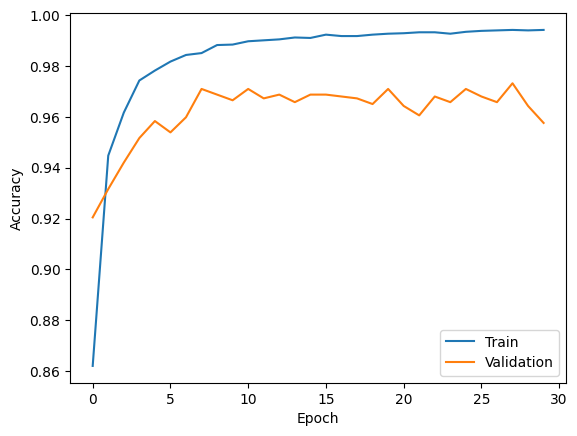

In [64]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


In [65]:
import numpy as np
print("Normal:", np.sum(y == 1))
print("Abnormal:", np.sum(y == 0))


Normal: 3692
Abnormal: 3029


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


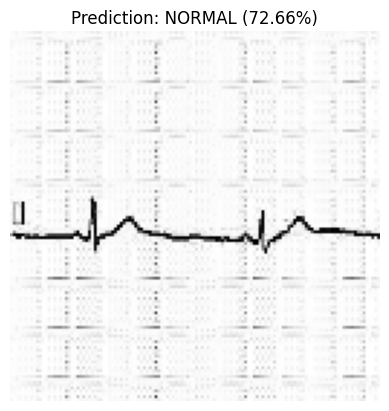

('NORMAL', np.float32(72.66174))

In [66]:
image_path = "/content/drive/MyDrive/LEADS/NORMAL/normal_image_102_lead_5.png"  # change path
predict_single_image(image_path)


In [67]:
model.save('capsnet_model.keras')

In [68]:
import tensorflow as tf

# Load the saved model
loaded_model = tf.keras.models.load_model('capsnet_model.keras')

# You can check its summary to confirm it's loaded correctly
loaded_model.summary()

TypeError: Could not locate class 'CapsNet'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': None, 'class_name': 'CapsNet', 'config': {'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}}, 'registered_name': 'CapsNet', 'build_config': {'input_shape': [None, 128, 128, 1]}, 'compile_config': {'optimizer': {'module': 'keras.optimizers', 'class_name': 'Adam', 'config': {'name': 'adam', 'learning_rate': 0.0010000000474974513, 'weight_decay': None, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}, 'registered_name': None}, 'loss': 'categorical_crossentropy', 'loss_weights': None, 'metrics': ['accuracy'], 'weighted_metrics': N

In [69]:
import cv2
import os
import numpy as np

image = cv2.imread("/content/drive/MyDrive/Colab Notebooks/OG_DATASET/Normal Person ECG Images (284x12=3408)/Normal(100).jpg")   # <-- put your ECG image path here


In [70]:
def split_13_leads_from_image(image, save_dir="temp_leads"):
    os.makedirs(save_dir, exist_ok=True)

    Lead_1  = image[300:600, 150:643]
    Lead_2  = image[300:600, 646:1135]
    Lead_3  = image[300:600, 1140:1625]
    Lead_4  = image[300:600, 1630:2125]

    Lead_5  = image[600:900, 150:643]
    Lead_6  = image[600:900, 646:1135]
    Lead_7  = image[600:900, 1140:1625]
    Lead_8  = image[600:900, 1630:2125]

    Lead_9  = image[900:1200, 150:643]
    Lead_10 = image[900:1200, 646:1135]
    Lead_11 = image[900:1200, 1140:1625]
    Lead_12 = image[900:1200, 1630:2125]

    Lead_13 = image[1250:1480, 150:2125]  # Long Lead II

    lead_images = [
        Lead_1, Lead_2, Lead_3, Lead_4,
        Lead_5, Lead_6, Lead_7, Lead_8,
        Lead_9, Lead_10, Lead_11, Lead_12,
        Lead_13
    ]

    lead_names = [
        "I", "aVR", "V1", "V4",
        "II", "aVL", "V2", "V5",
        "III", "aVF", "V3", "V6",
        "Lead_II_rhythm"
    ]

    for img, name in zip(lead_images, lead_names):
        cv2.imwrite(f"{save_dir}/{name}.png", img)

    print("✅ 13 ECG leads extracted using your coordinates")


In [71]:
def preprocess_lead(img_path, size=128):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (size, size))
    img = img / 255.0
    img = (img - img.mean()) / (img.std() + 1e-7)
    img = np.expand_dims(img, axis=-1)
    img = np.expand_dims(img, axis=0)
    return img


In [72]:
def predict_all_leads(model, lead_dir="temp_leads"):
    preds = {}

    for file in sorted(os.listdir(lead_dir)):
        if file.endswith(".png"):
            x = preprocess_lead(os.path.join(lead_dir, file))
            pred = model.predict(x, verbose=0)
            preds[file] = int(np.argmax(pred))  # 0 or 1

    return preds


In [73]:
def weighted_vote(preds):
    normal_count = 0
    abnormal_count = 0

    for lead, pred in preds.items():
        if pred == 1: # Normal
            normal_count += 1
        else: # Abnormal
            abnormal_count += 1

    # Return 1 for Normal if normal_count is greater, else 0 for Abnormal
    return 1 if normal_count > abnormal_count else 0

In [74]:
def full_ecg_prediction(model, image_path):
    image = cv2.imread(image_path)

    split_13_leads_from_image(image, "temp_leads")
    preds = predict_all_leads(model, "temp_leads")

    print("\n--- Lead-wise Predictions ---")
    for k, v in preds.items():
        print(k, "→", "Normal" if v==1 else "Abnormal")

    final = weighted_vote(preds)
    print("\n✅ FINAL ECG:", "Normal" if final==1 else "Abnormal")

    return final


In [75]:
import matplotlib.pyplot as plt

def show_cropped_leads(lead_dir="temp_leads"):
    files = sorted(os.listdir(lead_dir))

    plt.figure(figsize=(12, 8))

    for i, file in enumerate(files):
        img = cv2.imread(os.path.join(lead_dir, file), cv2.IMREAD_GRAYSCALE)

        plt.subplot(4, 4, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(file.replace(".png",""), fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [88]:
image = cv2.imread("/content/drive/MyDrive/Colab Notebooks/OG_DATASET/ECG Images of Patient that have abnormal heartbeat (233x12=2796)/HB(102).jpg")
split_13_leads_from_image(image, "temp_leads")


✅ 13 ECG leads extracted using your coordinates


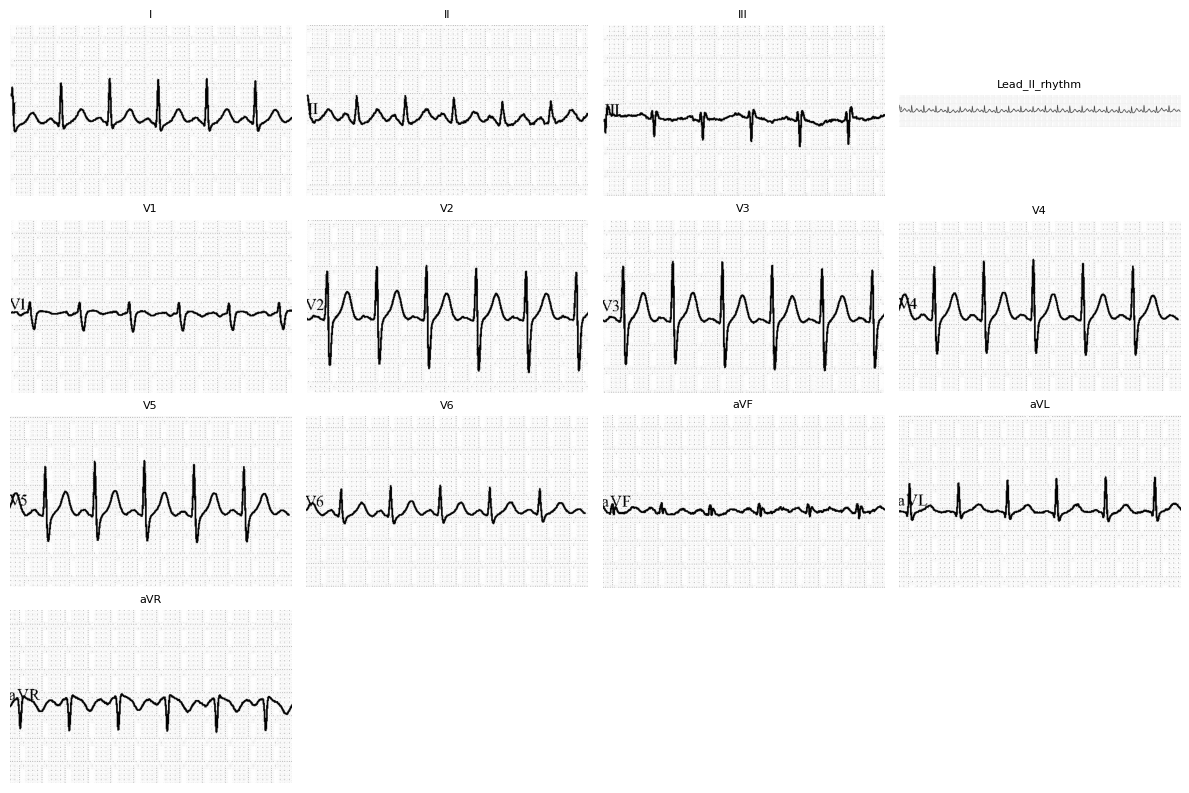

In [89]:
show_cropped_leads("temp_leads")

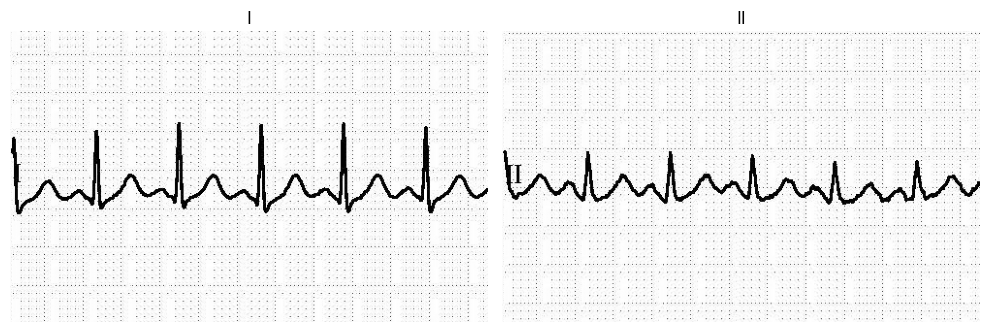

In [90]:
import cv2
import matplotlib.pyplot as plt
import os

lead_dir = "temp_leads"
leads_to_show = ["I.png", "II.png"] # You can change these to any other lead filenames

plt.figure(figsize=(10, 5))

for i, file_name in enumerate(leads_to_show):
    img_path = os.path.join(lead_dir, file_name)
    if os.path.exists(img_path):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        plt.subplot(1, len(leads_to_show), i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(file_name.replace(".png", ""))
        plt.axis("off")
    else:
        print(f"Warning: {file_name} not found in {lead_dir}")

plt.tight_layout()
plt.show()

In [104]:
full_ecg_prediction(model, "/content/drive/MyDrive/Colab Notebooks/OG_DATASET/Normal Person ECG Images (284x12=3408)/Normal(99).jpg")

✅ 13 ECG leads extracted using your coordinates

--- Lead-wise Predictions ---
I.png → Normal
II.png → Normal
III.png → Normal
Lead_II_rhythm.png → Normal
V1.png → Normal
V2.png → Normal
V3.png → Normal
V4.png → Normal
V5.png → Normal
V6.png → Normal
aVF.png → Normal
aVL.png → Normal
aVR.png → Normal

✅ FINAL ECG: Normal


1

In [85]:
preds = predict_all_leads(model, "temp_leads")

print("Lead-wise Predictions:")
for k, v in preds.items():
    print(f"{k} -> {'Normal' if v == 1 else 'Abnormal'}")

Lead-wise Predictions:
I.png -> Normal
II.png -> Normal
III.png -> Normal
Lead_II_rhythm.png -> Normal
V1.png -> Normal
V2.png -> Normal
V3.png -> Normal
V4.png -> Normal
V5.png -> Normal
V6.png -> Normal
aVF.png -> Normal
aVL.png -> Normal
aVR.png -> Normal


In [105]:
print("Train acc:", history.history['accuracy'][-1])
print("Val acc:", history.history['val_accuracy'][-1])


Train acc: 0.9942336082458496
Val acc: 0.9576207995414734
